# El ecosistema del dato: mapa, roles y lenguaje común
---

Esta sesión sirve para que todo lo que ya habéis aprendido —y lo que queda por aprender— tenga sentido dentro de un mapa común.

Al terminar esta sesión sabrás responder tres preguntas:

1. ¿Por qué existe todo esto?
2. ¿Cómo se llaman las piezas y dónde encajan?
3. ¿Qué rol puedo ocupar yo cuando acabe el curso?

---

## 1. Por qué existe el mundo del dato

### El problema de partida

Imagina una empresa mediana: tiene una tienda online, varias tiendas físicas, un sistema de nóminas y un CRM para gestionar clientes. Cada sistema genera datos todos los días.

El problema es que **esos datos no se hablan entre sí**.

- El equipo de ventas no sabe si un cliente que compró online también compró en tienda.
- Dirección pide un informe de ventas del trimestre y cada departamento da un número diferente.
- El responsable de marketing lanza una campaña sin saber si el stock aguanta la demanda.

Esto no es un problema de tecnología. Es un problema de **organización de la información**.

---

### La cadena de valor del dato

El mundo del dato existe para recorrer este camino:

```
FUENTE DE DATOS
      │
      ▼
  RECOGIDA Y TRANSPORTE          ← "alguien recoge el dato"
      │
      ▼
  ALMACENAMIENTO                 ← "alguien lo guarda bien"
      │
      ▼
  LIMPIEZA Y TRANSFORMACIÓN      ← "alguien lo deja utilizable"
      │
      ▼
  ANÁLISIS                       ← "alguien encuentra patrones"
      │
      ▼
  VISUALIZACIÓN                  ← "alguien lo hace comprensible"
      │
      ▼
  DECISIÓN DE NEGOCIO            ← "alguien actúa gracias al dato"
```

Cada paso del camino tiene su propio vocabulario, sus propias herramientas y su propio perfil profesional.  
El objetivo de este curso es que puedas trabajar en varios de esos pasos.

---


## 2. Las capas del ecosistema

Vamos a recorrer el ecosistema capa a capa, poniendo nombre a cada pieza.

---

### Vista general

```
┌─────────────────────────────────────────────────────────────────────┐
│  FUENTES          Tiendas · ERP · Web · Sensores · APIs · Excel     │
└──────────────────────────────┬──────────────────────────────────────┘
                               │
┌──────────────────────────────▼──────────────────────────────────────┐
│  INGESTA / ETL-ELT   Mover y transformar datos entre sistemas        │
└──────────────────────────────┬──────────────────────────────────────┘
                               │
┌──────────────────────────────▼──────────────────────────────────────┐
│  ALMACENAMIENTO      Data Lake · Data Warehouse · Data Lakehouse     │
│                      Capas:  Bronze → Silver → Gold                  │
└──────────────────────────────┬──────────────────────────────────────┘
                               │
┌──────────────────────────────▼──────────────────────────────────────┐
│  PROCESAMIENTO       SQL · Python/Pandas · Spark                     │
└──────────────────────────────┬──────────────────────────────────────┘
                               │
┌──────────────────────────────▼──────────────────────────────────────┐
│  ANÁLISIS            EDA · Machine Learning · Estadística            │
└──────────────────────────────┬──────────────────────────────────────┘
                               │
┌──────────────────────────────▼──────────────────────────────────────┐
│  VISUALIZACIÓN       Power BI · Tableau · Qlik · matplotlib         │
└──────────────────────────────┬──────────────────────────────────────┘
                               │
┌──────────────────────────────▼──────────────────────────────────────┐
│  DECISIÓN            El informe llega a quien tiene que actuar       │
└─────────────────────────────────────────────────────────────────────┘
```

---

### Las tres capas de almacenamiento: Bronze, Silver y Gold

Esta es una de las convenciones más extendidas en la industria y aparecerá muchas veces durante el curso.

| Capa | Qué contiene | Estado del dato |
|------|-------------|-----------------|
| **Bronze** | El dato tal como llega: crudo, sin tocar | Puede tener errores, duplicados, formatos raros |
| **Silver** | El dato limpio y validado | Normalizado, sin nulos problemáticos, tipado correcto |
| **Gold** | El dato listo para el negocio | Agregado, calculado, optimizado para dashboards o modelos |

---


In [ ]:
# Ilustración práctica: el viaje de un dato por las tres capas

import pandas as pd

# ── CAPA BRONZE: datos tal como llegan del sistema de ventas ──────────────────
bronze = pd.DataFrame({
    'cliente_id': ['C001', 'C002', 'C002', 'C003', None],
    'fecha':      ['2024-01-15', '2024-01-15', '2024-01-15', '2024-01-16', '2024-01-16'],
    'producto':   ['laptop', 'raton', 'raton', 'TECLADO', 'monitor'],
    'importe':    [899.0, 25.0, 25.0, 45.0, -10.0]  # hay un importe negativo sospechoso
})

print("=== CAPA BRONZE — datos crudos ===")
print(bronze.to_string())
print()

# ── CAPA SILVER: limpieza y validación ───────────────────────────────────────
silver = (bronze
    .dropna(subset=['cliente_id'])           # eliminar filas sin cliente
    .drop_duplicates()                       # eliminar duplicados exactos
    .assign(producto=lambda df: df['producto'].str.lower().str.strip())  # normalizar texto
    .query('importe > 0')                    # descartar importes inválidos
    .reset_index(drop=True)
)

print("=== CAPA SILVER — datos limpios ===")
print(silver.to_string())
print()

# ── CAPA GOLD: agregación para el negocio ────────────────────────────────────
gold = (silver
    .groupby('producto')['importe']
    .agg(total_ventas='sum', num_ventas='count')
    .reset_index()
    .sort_values('total_ventas', ascending=False)
)

print("=== CAPA GOLD — listo para el dashboard ===")
print(gold.to_string(index=False))


In [ ]:

# Visualización de las tres capas: Bronze → Silver → Gold

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

bronze = pd.DataFrame({
    'cliente_id': ['C001', 'C002', 'C002', 'C003', None],
    'producto':   ['laptop', 'raton', 'raton', 'TECLADO', 'monitor'],
    'importe':    [899.0, 25.0, 25.0, 45.0, -10.0]
})
silver = (bronze.dropna(subset=['cliente_id']).drop_duplicates()
          .assign(producto=lambda df: df['producto'].str.lower())
          .query('importe > 0').reset_index(drop=True))
gold = (silver.groupby('producto')['importe']
        .agg(total_ventas='sum', num_ventas='count')
        .reset_index().sort_values('total_ventas', ascending=False).reset_index(drop=True))

C_BRONZE, C_SILVER, C_GOLD = '#cd7f32', '#9e9e9e', '#c8a200'

fig = plt.figure(figsize=(15, 9))
fig.patch.set_facecolor('#f5f5f5')
fig.suptitle('Arquitectura Medallion: el viaje del dato por las tres capas',
             fontsize=15, fontweight='bold', y=0.99, color='#2c2c2c')

# ── Diagrama de flujo ─────────────────────────────────────────────────────────
ax_flow = fig.add_axes([0.03, 0.74, 0.94, 0.22])
ax_flow.set_xlim(0, 10); ax_flow.set_ylim(0, 1)
ax_flow.axis('off'); ax_flow.set_facecolor('#f5f5f5')

for x, color, nombre, sub1, sub2 in [
    (0.4,  C_BRONZE, 'BRONZE', 'Dato crudo · sin filtrar',   '⚠  duplicados, nulos, errores'),
    (3.75, C_SILVER, 'SILVER', 'Dato limpio · validado',      '✓  normalizado · sin anomalías'),
    (7.1,  C_GOLD,   'GOLD',   'Dato listo para el negocio',  '★  agregado · listo para dashboards'),
]:
    ax_flow.add_patch(mpatches.FancyBboxPatch((x, 0.08), 2.6, 0.84,
        boxstyle="round,pad=0.04", facecolor=color, edgecolor='white', linewidth=2.5, alpha=0.90, zorder=2))
    ax_flow.text(x+1.3, 0.74, nombre, ha='center', va='center', fontsize=13, fontweight='bold', color='white', zorder=3)
    ax_flow.text(x+1.3, 0.47, sub1,   ha='center', va='center', fontsize=8.5, color='white', zorder=3)
    ax_flow.text(x+1.3, 0.24, sub2,   ha='center', va='center', fontsize=8, color='white', alpha=0.9, style='italic', zorder=3)

for x_arrow, label in [(3.1, 'limpieza'), (6.45, 'agregación')]:
    ax_flow.annotate('', xy=(x_arrow+0.55, 0.5), xytext=(x_arrow, 0.5),
                     arrowprops=dict(arrowstyle='->', color='#555', lw=2.5), zorder=4)
    ax_flow.text(x_arrow+0.28, 0.67, label, ha='center', fontsize=7.5, color='#555', style='italic')

# ── Panel Bronze ──────────────────────────────────────────────────────────────
ax1 = fig.add_axes([0.03, 0.04, 0.30, 0.66])
ax1.set_facecolor('#fdf8f3'); ax1.axis('off')
ax1.set_title('Bronze — datos crudos', color=C_BRONZE, fontsize=11, fontweight='bold', pad=8)
bronze_str = [[str(v) if pd.notna(v) else 'None ⚠' for v in row] for _, row in bronze.iterrows()]
tbl1 = ax1.table(cellText=bronze_str, colLabels=bronze.columns.tolist(), cellLoc='center', loc='center')
tbl1.auto_set_font_size(False); tbl1.set_fontsize(9); tbl1.scale(1, 1.8)
for (r, c), cell in tbl1.get_celld().items():
    cell.set_edgecolor('#dddddd')
    if r == 0:   cell.set_facecolor(C_BRONZE); cell.set_text_props(color='white', fontweight='bold')
    elif r in (3, 4, 5): cell.set_facecolor('#ffe0e0')
    else: cell.set_facecolor('#fdf8f3' if r % 2 == 1 else '#fff5ee')
ax1.text(0.5, 0.01, '⚠  fila 3: duplicado  |  fila 4: None  |  fila 5: importe negativo',
         ha='center', va='bottom', transform=ax1.transAxes, fontsize=7.5, color='#cc4444', style='italic')

# ── Panel Silver ──────────────────────────────────────────────────────────────
ax2 = fig.add_axes([0.36, 0.04, 0.28, 0.66])
ax2.set_facecolor('#f5f5f5'); ax2.axis('off')
ax2.set_title('Silver — dato limpio', color='#666', fontsize=11, fontweight='bold', pad=8)
tbl2 = ax2.table(cellText=[[str(v) for v in row] for _, row in silver.iterrows()],
                  colLabels=silver.columns.tolist(), cellLoc='center', loc='center')
tbl2.auto_set_font_size(False); tbl2.set_fontsize(9); tbl2.scale(1, 1.8)
for (r, c), cell in tbl2.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if r == 0: cell.set_facecolor(C_SILVER); cell.set_text_props(color='white', fontweight='bold')
    else: cell.set_facecolor('#f8f8f8' if r % 2 == 1 else '#efefef')
ax2.text(0.5, 0.01, '✓  sin nulos · sin duplicados · valores normalizados',
         ha='center', va='bottom', transform=ax2.transAxes, fontsize=7.5, color='#3a7a3a', style='italic')

# ── Panel Gold ────────────────────────────────────────────────────────────────
ax3 = fig.add_axes([0.67, 0.12, 0.30, 0.55])
ax3.set_facecolor('#fffdf0')
ax3.set_title('Gold — listo para el dashboard', color=C_GOLD, fontsize=11, fontweight='bold', pad=8)
bars = ax3.barh(gold['producto'], gold['total_ventas'],
                color=['#ffd700', '#e6b800', '#cc9900'][:len(gold)], edgecolor='white', height=0.45)
for bar, val in zip(bars, gold['total_ventas']):
    ax3.text(bar.get_width()+8, bar.get_y()+bar.get_height()/2,
             f'{val:.0f} €', va='center', fontsize=9.5, fontweight='bold', color='#555')
ax3.set_xlabel('Total ventas (€)', fontsize=9, color='#666')
ax3.set_xlim(0, max(gold['total_ventas'])*1.30)
for spine in ('top', 'right'): ax3.spines[spine].set_visible(False)
for spine in ('left', 'bottom'): ax3.spines[spine].set_color('#cccccc')
ax3.tick_params(colors='#555', labelsize=9); ax3.set_facecolor('#fffdf0')
fig.text(0.82, 0.06, '★  agregado por producto · listo para Power BI / Tableau',
         ha='center', fontsize=7.5, color='#996600', style='italic')

plt.show()


**¿Qué acabas de ver?**

El mismo conjunto de datos recorre tres transformaciones:
- En **Bronze** está tal cual llega: con duplicados, un nulo y un valor negativo.
- En **Silver** está limpio y normalizado: solo datos válidos y coherentes.
- En **Gold** está agregado por producto: exactamente lo que aparecería en un dashboard de ventas.

Este patrón lo usarás en ETL, en Gobierno del Dato y cada vez que construyas un pipeline.

---


## 3. El glosario razonado

En lugar de una lista de definiciones, cada término está conectado a su capa y a su propósito.  
Si alguna vez no recuerdas qué significa algo, pregúntate: **¿en qué capa vive?**

---

### Términos de almacenamiento

| Término | Capa | Qué significa en la práctica |
|---------|------|------------------------------|
| **Data Lake** | Almacenamiento | Gran repositorio que guarda datos de cualquier tipo y formato, sin estructura obligatoria. Barato y flexible. Punto de entrada del dato crudo. |
| **Data Warehouse** | Almacenamiento | Base de datos estructurada y optimizada para consultas analíticas. Los datos ya están limpios y modelados. |
| **Data Mart** | Almacenamiento | Subconjunto de un Data Warehouse orientado a un área de negocio concreta (ventas, finanzas, marketing). Más pequeño y rápido de consultar; es lo que suele consumir directamente un equipo o un dashboard. |
| **Data Lakehouse** | Almacenamiento | Arquitectura que combina la flexibilidad del Data Lake con las capacidades analíticas del Data Warehouse. |
| **Data Mesh** | Organización | Enfoque donde cada equipo de negocio es responsable de sus propios datos. No es una tecnología, es una forma de organizarse. |
| **MDM** (Master Data Management) | Gobierno | Sistema que asegura que hay una única versión "oficial" de los datos maestros: clientes, productos, proveedores. |

---

### Términos de movimiento de datos

| Término | Capa | Qué significa en la práctica |
|---------|------|------------------------------|
| **ETL** (Extract, Transform, Load) | Ingesta | Primero transformas los datos y luego los cargas. El procesamiento ocurre antes de guardar. |
| **ELT** (Extract, Load, Transform) | Ingesta | Primero cargas los datos crudos y luego los transformas dentro del almacén. Más habitual en entornos cloud modernos. |
| **Pipeline** | Ingesta/Procesamiento | La cadena automatizada de pasos que mueve y transforma datos de un sitio a otro. |

---

### Términos de análisis y visualización

| Término | Capa | Qué significa en la práctica |
|---------|------|------------------------------|
| **KPI** (Key Performance Indicator) | Decisión | Una métrica concreta que mide el progreso hacia un objetivo. Ej: tasa de conversión, ticket medio. |
| **Dashboard** | Visualización | Panel visual que muestra KPIs y gráficos actualizados para facilitar la toma de decisiones. |
| **EDA** (Exploratory Data Analysis) | Análisis | Proceso de explorar un dataset para entender su estructura, detectar anomalías y formular hipótesis, antes de modelar. |
| **Modelo dimensional** | Almacenamiento/Análisis | Forma de organizar los datos en tablas de hechos (ventas, transacciones) y dimensiones (tiempo, cliente, producto). |
| **Schema-on-write** | Almacenamiento | El dato se estructura antes de guardarlo. Más rígido pero más rápido de consultar (Data Warehouse). |
| **Schema-on-read** | Almacenamiento | El dato se guarda tal cual y se estructura en el momento de leerlo. Más flexible (Data Lake). |

---

### Términos de gobierno y calidad

| Término | Capa | Qué significa en la práctica |
|---------|------|------------------------------|
| **Data Governance** | Transversal | Conjunto de políticas, roles y procesos que aseguran que los datos son fiables, seguros y bien gestionados. |
| **Metadata** | Transversal | Datos que describen otros datos. Ej: "este campo es de tipo fecha, fue creado el 2024-01-01, lo gestiona el equipo de ventas". |
| **RGPD / GDPR** | Gobierno | Reglamento europeo de protección de datos personales. Define qué puedes hacer con datos de personas. |

---

In [ ]:

# Mapa visual del glosario: cada término en su capa

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

capas = [
    ('Almacenamiento',       '#2980b9',
     ['Data Lake', 'Data Warehouse', 'Data Mart', 'Data Lakehouse', 'Data Mesh', 'MDM']),
    ('Ingesta / Movimiento', '#e67e22',
     ['ETL', 'ELT', 'Pipeline']),
    ('Análisis / Visual.',   '#27ae60',
     ['KPI', 'Dashboard', 'EDA', 'Modelo dimensional', 'Schema-on-write', 'Schema-on-read']),
    ('Gobierno / Calidad',   '#8e44ad',
     ['Data Governance', 'Metadata', 'RGPD / GDPR']),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 6))
fig.patch.set_facecolor('#f5f5f5')
fig.suptitle('Mapa del glosario — cada término en su capa', fontsize=13, fontweight='bold', y=1.01)

for ax, (titulo, color, items) in zip(axes, capas):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_facecolor('#f5f5f5')

    # cabecera
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.04, 0.88), 0.92, 0.10,
        boxstyle="round,pad=0.02", facecolor=color, edgecolor='none'))
    ax.text(0.50, 0.93, titulo, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='white')

    # términos
    n = len(items)
    slot = 0.82 / n
    for i, term in enumerate(items):
        y_center = 0.88 - slot * (i + 0.5)
        ax.add_patch(mpatches.FancyBboxPatch(
            (0.04, y_center - 0.032), 0.92, 0.064,
            boxstyle="round,pad=0.01", facecolor=color, edgecolor='none', alpha=0.18))
        ax.text(0.50, y_center, term, ha='center', va='center',
                fontsize=8.5, color='#222')

plt.tight_layout()
plt.show()


## 4. Las herramientas y dónde viven

Cada herramienta que aparece en el curso tiene un hogar dentro del ecosistema.  
La pregunta no es "¿para qué sirve esta herramienta?" sino "¿en qué parte del camino del dato la uso?"

---

```
CAPA                    HERRAMIENTA             ¿PARA QUÉ LA USAS?
─────────────────────────────────────────────────────────────────────────
Fuentes                 Excel, CSV, APIs        Punto de partida del dato

Ingesta / ETL           Python (Pandas)         Leer, limpiar, mover datos
                        SQL                     Consultar y transformar en BD

Almacenamiento          SQL + BD relacionales   Guardar datos estructurados
                        Cloud (AWS/GCP/Azure)   Almacenamiento escalable

Procesamiento           Python (Pandas, NumPy)  Transformar, calcular, filtrar
                        SQL avanzado            Joins, CTEs, vistas

Análisis                Python (scikit-learn)   Machine Learning, predicción
                        Estadística             Describir y entender los datos

Visualización           Power BI                Dashboards de negocio
                        Tableau                 Análisis visual e interactivo
                        Qlik                    Dashboards con modelo asociativo
                        matplotlib / seaborn    Gráficos en Python

Decisión                Todo lo anterior        El dato llega a quien actúa
─────────────────────────────────────────────────────────────────────────
```

---

**Nota importante:** ninguna herramienta es "la mejor".  
Cada una existe porque resuelve bien un problema concreto en una capa concreta.  
Un profesional del dato sabe elegir la herramienta adecuada para cada momento.

---


## 5. Los roles profesionales

El ecosistema del dato no lo gestiona una sola persona. Hay distintos perfiles especializados,  
cada uno con su zona de actuación principal dentro del mapa.

---

### Los cinco roles principales

```
┌────────────────────────────────────────────────────────────────────────┐
│                                                                        │
│   DATA ENGINEER          Construye los caminos por los que viajan      │
│   ─────────────          los datos. Pipelines, almacenes, ETL.         │
│   Zona: Fuentes → Ingesta → Almacenamiento                             │
│                                                                        │
├────────────────────────────────────────────────────────────────────────┤
│                                                                        │
│   DATA ANALYST           Explora los datos ya preparados y extrae      │
│   ───────────            conclusiones útiles para el negocio.          │
│   Zona: Procesamiento → Análisis → Visualización                       │
│                                                                        │
├────────────────────────────────────────────────────────────────────────┤
│                                                                        │
│   BI DEVELOPER           Diseña y construye los dashboards e           │
│   ────────────           informes que llegan a dirección.              │
│   Zona: Almacenamiento Gold → Visualización → Decisión                 │
│                                                                        │
├────────────────────────────────────────────────────────────────────────┤
│                                                                        │
│   DATA SCIENTIST         Construye modelos predictivos y aplica        │
│   ─────────────          estadística avanzada y machine learning.      │
│   Zona: Procesamiento → Análisis (modelado)                            │
│                                                                        │
├────────────────────────────────────────────────────────────────────────┤
│                                                                        │
│   DATA STEWARD /         Asegura que los datos son fiables, están      │
│   GOVERNANCE             bien documentados y cumplen la normativa.     │
│   ───────────            Zona: Transversal (todas las capas)           │
│                                                                        │
└────────────────────────────────────────────────────────────────────────┘
```

---


--- DATA ENGINEER: entrega este dataset limpio y tipado ---
region      object
mes         object
ventas       int64
objetivo     int64
dtype: object

--- DATA ANALYST: analiza tendencias y desviaciones ---
region     mes  ventas  objetivo  desviacion  cumple
 Norte   Enero   12400     12000         400    True
   Sur   Enero    9800     10000        -200   False
  Este   Enero   15200     14000        1200    True
 Oeste   Enero    8700      9000        -300   False
 Norte Febrero   13100     13000         100    True
   Sur Febrero   10200     10500        -300   False
  Este Febrero   14800     15000        -200   False
 Oeste Febrero    9300      9500        -200   False

--- DATA SCIENTIST: calcula correlación y proyección simple ---
Crecimiento Enero→Febrero por región:
region
Norte    700
Oeste    600
Sur      400
Este    -400

--- BI DEVELOPER: prepara los datos para el dashboard ---
        total_ventas  total_objetivo  cumplimiento
region                                      

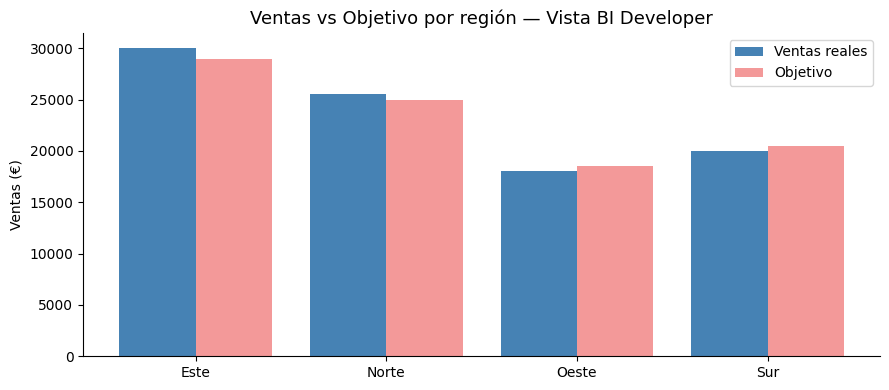

--- DATA STEWARD: documenta el campo 'ventas' ---
Campo: ventas | Tipo: float | Propietario: Equipo Comercial
Descripción: Importe total de ventas brutas por región y mes, en euros.
Fuente: Sistema ERP SAP. Actualización: mensual. Sensibilidad: interna.


In [2]:
# Ilustración: el output típico de cada rol sobre el mismo dataset

import pandas as pd
import matplotlib.pyplot as plt

# Dataset de partida: ventas por región
datos = pd.DataFrame({
    'region':   ['Norte', 'Sur', 'Este', 'Oeste', 'Norte', 'Sur', 'Este', 'Oeste'],
    'mes':      ['Enero', 'Enero', 'Enero', 'Enero', 'Febrero', 'Febrero', 'Febrero', 'Febrero'],
    'ventas':   [12400, 9800, 15200, 8700, 13100, 10200, 14800, 9300],
    'objetivo': [12000, 10000, 14000, 9000, 13000, 10500, 15000, 9500]
})

print("--- DATA ENGINEER: entrega este dataset limpio y tipado ---")
print(datos.dtypes)
print()

print("--- DATA ANALYST: analiza tendencias y desviaciones ---")
datos['desviacion'] = datos['ventas'] - datos['objetivo']
datos['cumple'] = datos['desviacion'] >= 0
print(datos[['region', 'mes', 'ventas', 'objetivo', 'desviacion', 'cumple']].to_string(index=False))
print()

print("--- DATA SCIENTIST: calcula correlación y proyección simple ---")
crecimiento = datos.groupby('region')['ventas'].apply(lambda x: x.iloc[-1] - x.iloc[0])
print("Crecimiento Enero→Febrero por región:")
print(crecimiento.sort_values(ascending=False).to_string())
print()

print("--- BI DEVELOPER: prepara los datos para el dashboard ---")
resumen_gold = datos.groupby('region').agg(
    total_ventas=('ventas', 'sum'),
    total_objetivo=('objetivo', 'sum')
).assign(cumplimiento=lambda df: (df['total_ventas'] / df['total_objetivo'] * 100).round(1))
print(resumen_gold.to_string())
print()

# Gráfico — lo que vería un BI Developer en su herramienta de visualización
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(resumen_gold))
ax.bar([i - 0.2 for i in x], resumen_gold['total_ventas'], width=0.4,
       label='Ventas reales', color='steelblue')
ax.bar([i + 0.2 for i in x], resumen_gold['total_objetivo'], width=0.4,
       label='Objetivo', color='lightcoral', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(resumen_gold.index)
ax.set_title('Ventas vs Objetivo por región — Vista BI Developer', fontsize=13)
ax.set_ylabel('Ventas (€)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print("--- DATA STEWARD: documenta el campo 'ventas' ---")
print("Campo: ventas | Tipo: float | Propietario: Equipo Comercial")
print("Descripción: Importe total de ventas brutas por región y mes, en euros.")
print("Fuente: Sistema ERP SAP. Actualización: mensual. Sensibilidad: interna.")


**¿Qué acabas de ver?**

Los cinco roles trabajan sobre el **mismo dataset**, pero con objetivos distintos:

- El **Data Engineer** lo entrega limpio y bien tipado.
- El **Data Analyst** detecta qué regiones cumplen el objetivo.
- El **Data Scientist** calcula tendencias y proyecciones.
- El **BI Developer** construye la vista agregada para el dashboard.
- El **Data Steward** documenta de dónde viene el dato y quién lo gestiona.

No son roles competidores: son complementarios. En empresas pequeñas, una misma persona puede hacer varios de estos roles.

---


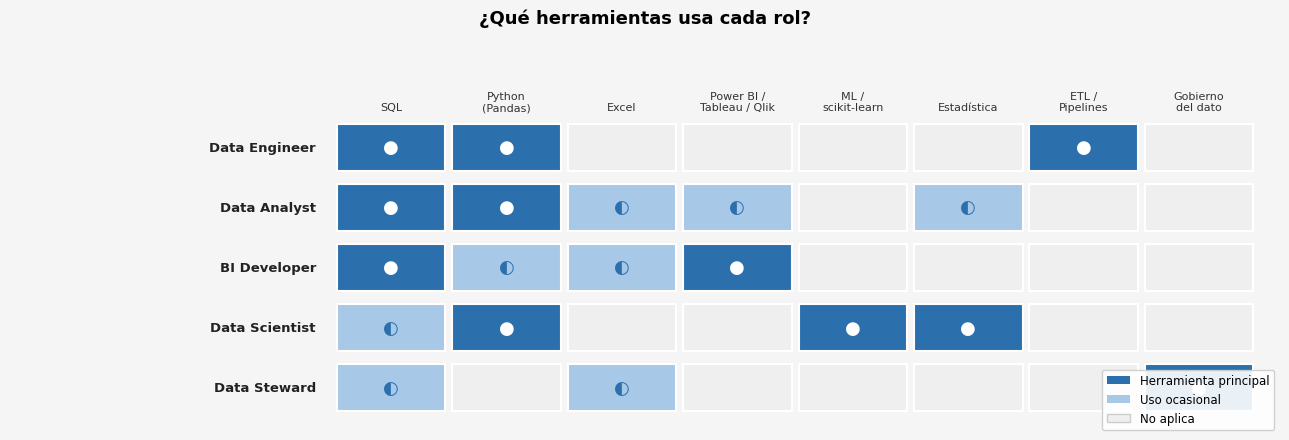

In [4]:

# Matriz: ¿qué herramientas usa cada rol?

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

roles = ['Data Engineer', 'Data Analyst', 'BI Developer', 'Data Scientist', 'Data Steward']
tools = ['SQL', 'Python\n(Pandas)', 'Excel', 'Power BI /\nTableau / Qlik',
         'ML /\nscikit-learn', 'Estadística', 'ETL /\nPipelines', 'Gobierno\ndel dato']

# 2 = herramienta principal  |  1 = uso ocasional  |  0 = no aplica
matriz = [
    [2, 2, 0, 0, 0, 0, 2, 0],   # Data Engineer
    [2, 2, 1, 1, 0, 1, 0, 0],   # Data Analyst
    [2, 1, 1, 2, 0, 0, 0, 0],   # BI Developer
    [1, 2, 0, 0, 2, 2, 0, 0],   # Data Scientist
    [1, 0, 1, 0, 0, 0, 0, 2],   # Data Steward
]

C_PRINCIPAL = '#2c6fad'
C_OCASIONAL = '#a8c8e8'
C_NONE      = '#efefef'

fig, ax = plt.subplots(figsize=(13, 4.5))
fig.patch.set_facecolor('#f5f5f5')
ax.set_facecolor('#f5f5f5')
ax.set_title('¿Qué herramientas usa cada rol?', fontsize=13, fontweight='bold', pad=14)

nr, nc = len(roles), len(tools)

for r, fila in enumerate(matriz):
    for c, val in enumerate(fila):
        color     = C_PRINCIPAL if val == 2 else (C_OCASIONAL if val == 1 else C_NONE)
        symbol    = '●' if val == 2 else ('◐' if val == 1 else '')
        sym_color = 'white' if val == 2 else ('#2c6fad' if val == 1 else '#ccc')

        ax.add_patch(plt.Rectangle(
            (c + 0.03, nr - r - 1 + 0.08), 0.94, 0.78,
            facecolor=color, edgecolor='white', linewidth=1.5))
        if symbol:
            ax.text(c + 0.50, nr - r - 1 + 0.47, symbol,
                    ha='center', va='center', fontsize=13, color=sym_color)

# etiquetas columnas
for c, tool in enumerate(tools):
    ax.text(c + 0.50, nr + 0.05, tool,
            ha='center', va='bottom', fontsize=8, color='#333', multialignment='center')

# etiquetas filas
for r, rol in enumerate(roles):
    ax.text(-0.15, nr - r - 1 + 0.47, rol,
            ha='right', va='center', fontsize=9.5, color='#222', fontweight='bold')

# leyenda
leyenda = [
    mpatches.Patch(facecolor=C_PRINCIPAL, label='Herramienta principal'),
    mpatches.Patch(facecolor=C_OCASIONAL, label='Uso ocasional'),
    mpatches.Patch(facecolor=C_NONE, edgecolor='#ccc', label='No aplica'),
]
ax.legend(handles=leyenda, loc='lower right', fontsize=8.5, framealpha=0.9,
          bbox_to_anchor=(1.0, -0.02))

ax.set_xlim(-2.8, nc + 0.2)
ax.set_ylim(-0.2, nr + 1.2)
ax.axis('off')

plt.tight_layout()
plt.show()


## 6. Cómo encaja lo que estáis aprendiendo

Ahora que tienes el mapa completo, ubiquemos los bloques del curso dentro de él.

---

### Bloques del curso y su lugar en el ecosistema

| Bloque | Capa del ecosistema | Rol al que principalmente prepara |
|--------|--------------------|------------------------------------|
| **SQL y Bases de Datos** | Almacenamiento · Procesamiento | Data Engineer · Data Analyst |
| **Python Fundamentos y Avanzado** | Procesamiento · Ingesta | Data Engineer · Data Scientist |
| **EDA y Python Integrado** | Análisis | Data Analyst · Data Scientist |
| **Estadística Aplicada** | Análisis | Data Scientist · Data Analyst |
| **ETL / ELT** | Ingesta | Data Engineer |
| **Power BI · Tableau · Qlik** | Visualización | BI Developer · Data Analyst |
| **Gobierno del Dato** | Gobierno | Data Steward |
| **Cloud e IA** | Almacenamiento · Análisis | Data Engineer · Data Scientist |

---

### ¿A qué roles podéis aspirar al terminar?

```
PERFIL MÁS ACCESIBLE AL SALIR          PERFIL CON ESPECIALIZACIÓN ADICIONAL
────────────────────────────────────    ──────────────────────────────────────
Data Analyst                            Data Engineer  (más Python y Cloud)
BI Developer                            Data Scientist  (más estadística y ML)
Data Steward  (Gobierno)                Analytics Engineer  (dbt, modelado avanzado)
```

---

## 7. El mercado laboral en España

Un poco de contexto práctico: los perfiles de datos tienen alta demanda y salarios por encima de la media tecnológica.

---

### Rangos salariales orientativos (España, 2024–2025)

| Rol | Junior (0–2 años) | Mid (2–5 años) | Senior (5+ años) |
|-----|:-----------------:|:--------------:|:----------------:|
| **Data Analyst** | 22.000 – 30.000 € | 30.000 – 42.000 € | 42.000 – 58.000 € |
| **BI Developer** | 24.000 – 33.000 € | 33.000 – 46.000 € | 46.000 – 62.000 € |
| **Data Engineer** | 28.000 – 38.000 € | 38.000 – 55.000 € | 55.000 – 75.000 € |
| **Data Scientist** | 28.000 – 38.000 € | 38.000 – 55.000 € | 55.000 – 80.000 € |
| **Data Steward** | 22.000 – 30.000 € | 30.000 – 42.000 € | 40.000 – 55.000 € |

*Rangos brutos anuales orientativos. Fuente: Infojobs, Glassdoor, LinkedIn Jobs.*

---

### Sectores con mayor demanda de perfiles de datos

| Sector | Roles más buscados |
|--------|-------------------|
| Banca y seguros | Data Engineer · Data Scientist · Data Governance |
| Retail y e-commerce | Data Analyst · BI Developer · Data Engineer |
| Salud y farmacéutica | Data Scientist · Data Analyst |
| Telecomunicaciones | Data Engineer · Data Scientist |
| Consultoría tecnológica | Todos los perfiles |
| Administración pública | Data Steward · Data Analyst |

---

### Dónde buscar ofertas

- **LinkedIn Jobs** — mayor volumen de ofertas de datos en España.
- **Infojobs** — fuerte en empresas nacionales medianas y grandes.
- **Glassdoor** — útil para contrastar salarios reales.
- **Tecnoempleo** — especializado en tecnología en España.

---

---

### Para recordar

El ecosistema del dato no es un conjunto de herramientas sueltas que hay que memorizar.  
Es una **cadena de valor** donde cada pieza tiene su lugar y su propósito.

Cada vez que trabajéis con SQL, con Python o con Power BI, preguntaos:  
**¿en qué capa del mapa estoy ahora? ¿Qué problema estoy resolviendo?**

Esa pregunta es la que separa a alguien que usa herramientas de alguien que entiende el dato.

---